In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

In [4]:
df_subset = pd.read_parquet('dataset_with_fpts_subset.parquet')

In [5]:
df_subset

,rnacentral_id,taxid,description,rna_type,so_rna_type,databases,secondary_structure,sequence,length,gc_content,...,min_12_tree_dist,min_13_tree_dist,min_14_tree_dist,min_15_tree_dist,min_16_tree_dist,min_17_tree_dist,min_18_tree_dist,min_19_tree_dist,min_20_tree_dist,fpts
0,URS0000471323_9606,9606,Homo sapiens (human) tRNA-Thr,tRNA,SO:0000253,ENA,,CUUUUUCCAAGGACA,15,0.400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.3269999921321869, 1.475000023841858, 2.9560..."
1,URS0000DEB820_9606,9606,Homo sapiens (human) partial tRNA-Ala,tRNA,SO:0000253,ENA,,GUUUUGCAGUCCUUA,15,0.400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[1.246000051498413, 1.8930000066757202, 0.2829..."
2,URS0002086B80_9606,9606,Homo sapiens (human) partial tRNA-Trp,tRNA,SO:0000253,ENA,,UGCAAUACUUAAUUU,15,0.200000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.42800000309944153, 3.052000045776367, 0.818..."
3,URS00007BEABE_9606,9606,Homo sapiens (human) partial tRNA-Pro,tRNA,SO:0000253,ENA,,AGACUUUUUCUCUGA,15,0.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[1.0069999694824219, 1.4730000495910645, 1.753..."
4,URS0000818973_9606,9606,Homo sapiens (human) partial tRNA-Pro,tRNA,SO:0000253,ENA,,CAGAGAAUAGUUUAA,15,0.266667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.6549999713897705, 0.3479999899864197, 4.708..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8306,URS00003D1FB8_9606,9606,Homo sapiens (human) scRNA-hY3_RNA-related,Y_RNA,SO:0000405,ENA,((((((((.((..(((((((.(.....(((.((................,GGCUGGUCCGAGUGUAUUGGUGUUUAGAACUAAUUCAUCACAACCA...,100,0.420000,...,54.0,56.0,28.0,28.0,28.0,28.0,20.0,30.0,44.0,"[75480.21, 3382619.0, 841122.0, 1466693.0, 218..."
8307,URS0000E3E073_9606,9606,Homo sapiens (human) partial 16S ribosomal RNA,rRNA,SO:0000252,ENA,..((......(((..((((.....))))..))).(((....)))))...,GCAGUAAAUGGCUAAGACUUCACCAGUCAAAGCGAACUACUAUACU...,100,0.430000,...,4.0,16.0,46.0,4.0,44.0,42.0,4.0,20.0,4.0,"[2951.14306640625, 7230.98876953125, 23244.396..."
8308,URS000072A9E4_9606,9606,Homo sapiens (human) Y RNA,Y_RNA,SO:0000405,Rfam,((((((((.((..(.(((((.........(((.((..............,GGCUGGUCCGAGUGCAGUGGUUUAUGACUAAUUAAUCACAACCAGU...,100,0.440000,...,36.0,4.0,12.0,26.0,30.0,6.0,36.0,36.0,36.0,"[606.6240234375, 3034.006103515625, 2167.71606..."
8309,URS0000A85A55_9606,9606,Homo sapiens (human) Y RNA (ENSG00000252266.1),Y_RNA,SO:0000405,"Ensembl,Expression Atlas,GeneCards",((((((((.((..(((((((.(.....(((.((................,AAUUGGUCUAAGUAUAGUGGUGUUUAUAACUAAUUGAUCACAAGUG...,100,0.350000,...,4.0,10.0,14.0,12.0,40.0,32.0,18.0,14.0,6.0,"[5240.0888671875, 245545.015625, 3194.72998046..."


In [6]:
arr_all_fpts = np.stack(df_subset['fpts'].values)
print(arr_all_fpts.shape)

(8311, 1000)


In [7]:
min_log_fpt = 0
max_log_fpt = 0

for row in df_subset.itertuples():
    data = row.fpts
    where_data_zero = np.where(data == 0)[0]
    if len(where_data_zero) != 0:
        print(row.Index, len(where_data_zero))
        
    where_data_nonzero = np.where(data != 0)[0]
    log_data = np.log10(data[where_data_nonzero])
    
    min_log_fpt = min(min(log_data), min_log_fpt)
    max_log_fpt = max(max(log_data), max_log_fpt)

print(f'Min log FPT: {min_log_fpt}, Max log FPT: {max_log_fpt}')

1 1
6 1
9 1
16 1
18 1
23 3
24 1
32 2
34 1
48 1
49 1
51 1
53 1
59 1
60 1
65 2
66 1
70 1
80 2
82 2
95 1
96 2
100 1
114 2
118 1
119 1
126 1
128 1
132 2
138 1
144 1
152 1
153 2
159 1
162 1
169 1
170 1
171 1
178 1
183 1
200 1
215 1
219 3
223 1
239 3
244 1
245 1
249 4
251 1
259 2
269 1
274 2
282 1
284 1
290 1
292 1
300 1
303 1
304 1
309 3
321 1
326 1
331 1
337 3
342 1
352 1
358 1
362 2
363 1
367 1
369 1
373 1
383 1
393 2
396 1
410 1
422 2
430 1
433 1
444 1
455 1
459 1
478 1
480 2
500 2
527 1
536 3
537 1
539 1
557 1
563 1
573 1
577 2
581 1
584 2
585 1
586 1
591 2
592 1
593 2
597 1
604 1
612 1
643 3
657 1
675 2
682 1
696 1
702 1
708 1
712 1
717 2
722 1
730 1
758 1
761 1
771 2
783 1
784 1
793 1
812 1
813 1
835 2
839 1
852 2
873 1
879 1
883 2
885 1
887 1
891 2
896 1
898 1
914 1
916 1
927 1
953 2
955 1
956 1
957 1
958 1
976 1
978 2
979 2
981 1
987 1
998 1
999 1
1014 1
1025 2
1027 2
1048 1
1052 1
1074 2
1084 1
1106 2
1112 2
1113 1
1118 1
1121 1
1123 1
1126 1
1131 1
1135 2
1140 4
1141 1
1148 2
1154

In [8]:
for row in df_subset.itertuples():
    print(row.length)

15
15
15
15
15
15
15
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
1

In [9]:
for row in df_subset.itertuples():
    print(row.Index)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

Text(0.75, 0.95, '19')

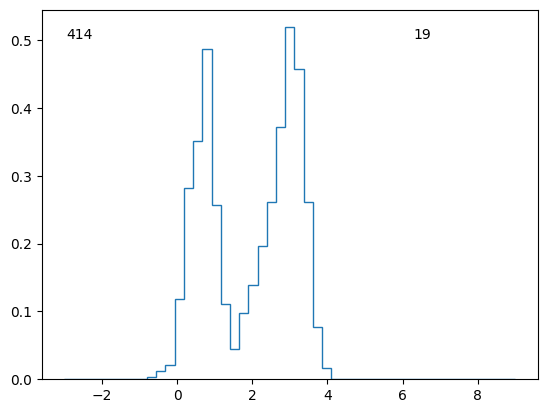

In [10]:
num_bins = 50
binedges_log_fpt = np.linspace(min_log_fpt, max_log_fpt, num_bins)

i_row = 414

data = df_subset['fpts'][i_row]
where_data_zero = np.where(data == 0)[0]        
where_data_nonzero = np.where(data != 0)[0]
log_data = np.log10(data[where_data_nonzero])

hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)

fig, ax = plt.subplots()
ax.stairs(hist_log_fpt, binedges_log_fpt)
# ax.set_xticks([])
# ax.set_yticks([])
ax.text(0.05, 0.95, str(i_row), transform=ax.transAxes, verticalalignment='top')
ax.text(0.75, 0.95, str(df_subset['length'][i_row]), transform=ax.transAxes, verticalalignment='top')

In [11]:
numpoints_kdegrid = 1000
kdegrid_log_fpt = np.linspace(min_log_fpt, max_log_fpt, numpoints_kdegrid)
spacing_kdegrid = kdegrid_log_fpt[1] - kdegrid_log_fpt[0]

def gauss_kernel(kdegrid_log_fpt, mean, stdev):
    return 1/np.sqrt(2*np.pi*stdev**2)*np.exp(-0.5*((kdegrid_log_fpt - mean)/stdev)**2)

list_stdev = [1,0.1,0.01]
list_kde = []

for i in range(len(list_stdev)):
    kde = np.zeros(numpoints_kdegrid)
    for j in range(log_data.size):
        kde += 1/(log_data.size)*gauss_kernel(kdegrid_log_fpt, log_data[j], list_stdev[i])
    list_kde.append(kde)

Text(0.75, 0.95, '19')

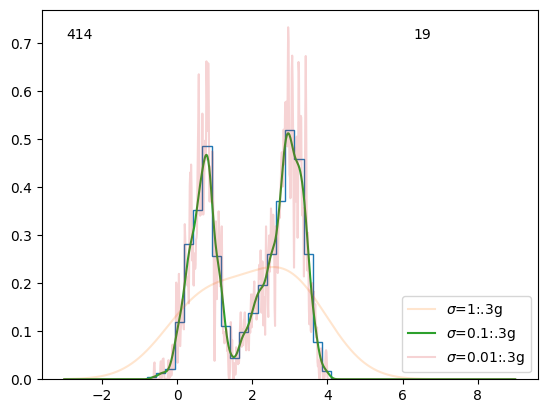

In [12]:
fig, ax = plt.subplots()
ax.stairs(hist_log_fpt, binedges_log_fpt)
for i in range(len(list_stdev)):
    if list_stdev[i] == 0.1:
        alpha = 1.0
    else:
        alpha = 0.2
    ax.plot(kdegrid_log_fpt, list_kde[i], label=r'$\sigma$'+f'={list_stdev[i]}:.3g', alpha=alpha)

ax.legend()
ax.text(0.05, 0.95, str(i_row), transform=ax.transAxes, verticalalignment='top')
ax.text(0.75, 0.95, str(df_subset['length'][i_row]), transform=ax.transAxes, verticalalignment='top')

138


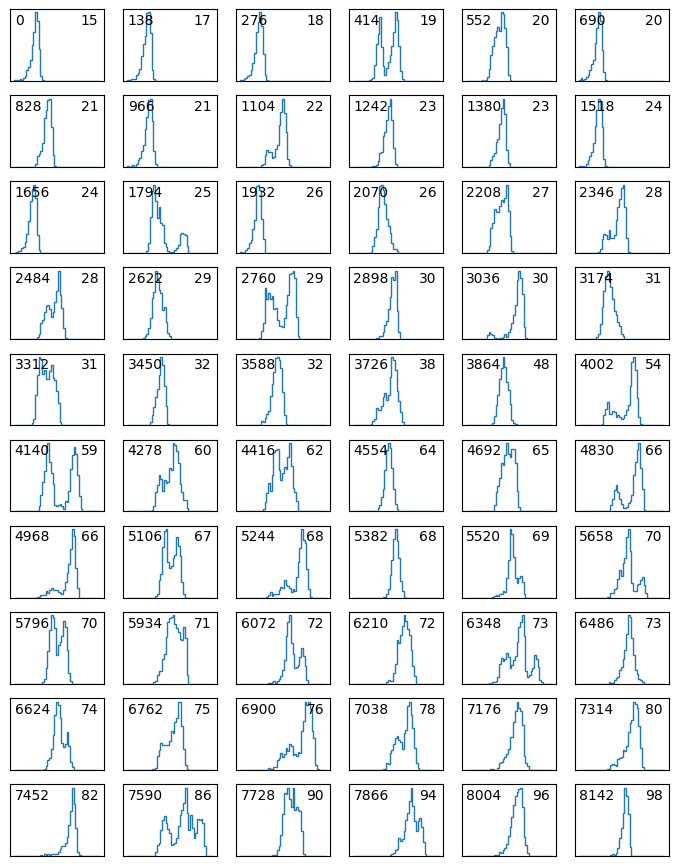

In [ ]:
num_bins = 50
binedges_log_fpt = np.linspace(min_log_fpt, max_log_fpt, num_bins)

width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

row_stride = int(len(df_subset)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_subset.itertuples():
    if row.Index % row_stride == 0:
        data = row.fpts
        where_data_zero = np.where(data == 0)[0]        
        where_data_nonzero = np.where(data != 0)[0]
        log_data = np.log10(data[where_data_nonzero])
        
        hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)
        
        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.stairs(hist_log_fpt, binedges_log_fpt)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('hist_log_fpt.pdf', bbox_inches='tight', pad_inches=0.25)

138


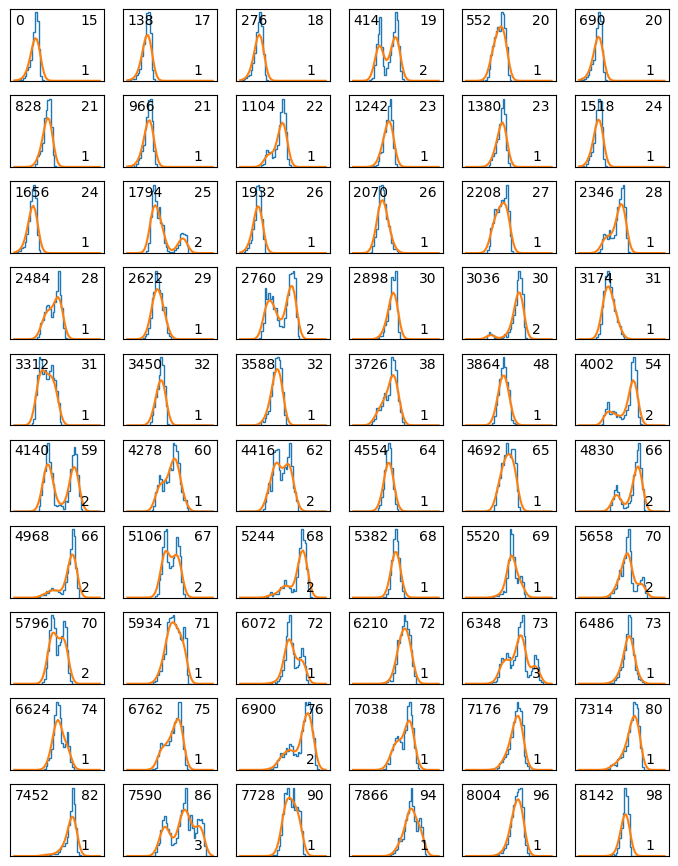

In [ ]:
num_bins = 50
binedges_log_fpt = np.linspace(min_log_fpt, max_log_fpt, num_bins)

numpoints_kdegrid = 50
kdegrid_log_fpt = np.linspace(min_log_fpt, max_log_fpt, numpoints_kdegrid)
spacing_kdegrid = kdegrid_log_fpt[1] - kdegrid_log_fpt[0]
stdev = 0.5

def gauss_kernel(kdegrid_log_fpt, mean, stdev):
    return 1/np.sqrt(2*np.pi*stdev**2)*np.exp(-0.5*((kdegrid_log_fpt - mean)/stdev)**2)

width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

row_stride = int(len(df_subset)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_subset.itertuples():
    if row.Index % row_stride == 0:
        data = row.fpts
        where_data_zero = np.where(data == 0)[0]        
        where_data_nonzero = np.where(data != 0)[0]
        log_data = np.log10(data[where_data_nonzero])
        
        hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)
        
        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.stairs(hist_log_fpt, binedges_log_fpt)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')

        # KDE (Kernel Density Estimation)
        kde = np.zeros(numpoints_kdegrid)
        for j in range(log_data.size):
            kde += 1/(log_data.size)*gauss_kernel(kdegrid_log_fpt, log_data[j], stdev)
        
        # number of peaks
        peak_indices, _ = find_peaks(kde)
        num_peaks = len(peak_indices)
        ax.text(0.75, 0.05, str(num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        ax.plot(kdegrid_log_fpt, kde)

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('hist_kde_log_fpt.pdf', bbox_inches='tight', pad_inches=0.25)

In [15]:
df_subset['num_peaks'] = None

numpoints_kdegrid = 50
kdegrid_log_fpt = np.linspace(min_log_fpt, max_log_fpt, numpoints_kdegrid)
spacing_kdegrid = kdegrid_log_fpt[1] - kdegrid_log_fpt[0]
stdev = 0.5

def gauss_kernel(kdegrid_log_fpt, mean, stdev):
    return 1/np.sqrt(2*np.pi*stdev**2)*np.exp(-0.5*((kdegrid_log_fpt - mean)/stdev)**2)

row_stride = 100
for row in df_subset.itertuples():
    if row.Index % row_stride == 0:
        print(row.Index)
    data = row.fpts
    where_data_zero = np.where(data == 0)[0]        
    where_data_nonzero = np.where(data != 0)[0]
    log_data = np.log10(data[where_data_nonzero])

    # KDE (Kernel Density Estimation)
    kde = np.zeros(numpoints_kdegrid)
    for j in range(log_data.size):
        kde += 1/(log_data.size)*gauss_kernel(kdegrid_log_fpt, log_data[j], stdev)
    
    # number of peaks
    peak_indices, _ = find_peaks(kde)
    num_peaks = len(peak_indices)
    df_subset.loc[row.Index, 'num_peaks'] = num_peaks

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300


In [52]:
arr_num_peaks = np.array(df_subset['num_peaks'])

In [54]:
arr_num_peaks[arr_num_peaks==1].size

6004

In [55]:
arr_num_peaks[arr_num_peaks==2].size

2217

In [56]:
arr_num_peaks[np.logical_and(arr_num_peaks!=1, arr_num_peaks!=2)].size

90

(array([6004.,    0.,    0.,    0.,    0., 2217.,    0.,    0.,    0.,
          90.]),
 array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. ]),
 <BarContainer object of 10 artists>)

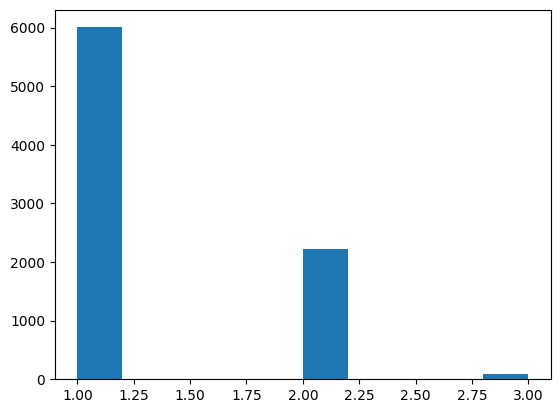

In [60]:
plt.hist(arr_num_peaks)

In [2]:
mask_rows_numpeaks1or2 = df_subset['num_peaks'].apply(lambda n: (n == 1) or (n == 2))
df_subset_numpeaks1or2 = df_subset[mask_rows_numpeaks1or2]

NameError: name 'df_subset' is not defined

In [58]:
len(df_subset_numpeaks1or2)

8221

In [61]:
df_subset_numpeaks1or2.to_parquet('dataset_with_fpts_subset_numpeaks1or2.parquet', index=False)